
### Module Import & Settings

In [1]:
#%pip install seaborn matplotlib pandas numpy shap scikit-learn
import seaborn as sns
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import ast
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

%config InlineBackend.figure_formats = ['svg']

# Set scientific style
font_size = 11

sns.set_theme(
    style="whitegrid",
    context="paper",
    palette="colorblind",
    font_scale=1.0
)

plt.rcParams.update({
    "text.usetex": False,                 
    "font.family": "serif",               
    "font.serif": ["Times New Roman", "Times", "Computer Modern Roman", "serif"],    
    "mathtext.fontset": "stix",           
    "axes.linewidth": 1.0,
    "grid.linewidth": 0.5
})

# 1. BildgrÃƒÂ¶ÃƒÅ¸e berechnen (Textbreite: 153mm) - Adam bitte checken
width_in_inches = 153 / 25.4 
# HÃƒÂ¶he berechnen (goldener Schnitt)
height_in_inches = width_in_inches / 1.618

# --- STEP 1: Data Acquisition ---
# Load datasets (Assuming filenames are correct) 
df = pd.read_csv('../results/experiments/full_analysis.csv') 

c:\Users\Altenbuchner\Nextcloud\Doktorarbeit\Veröffentlichungen\P4 Knowledge\icme\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


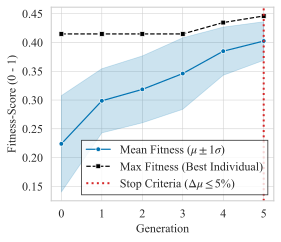

In [2]:
# Prepare data from the dataframe
data_max = df.groupby('gen')['fitness'].max()

# --- Visualization Setup ---
fig, ax = plt.subplots(figsize=(4, 3.5))

def plot_on_axis(ax, df, data_max, title, stop_gen=None, fontsize=12):
    # Plot Mean Fitness with standard deviation
    sns.lineplot(
        data=df, x='gen', y='fitness', errorbar='sd', marker='o', 
        ax=ax, label=r'Mean Fitness ($\mu \pm 1\sigma$)' 
    )
    
    # Plot Max Fitness
    sns.lineplot(
        x=data_max.index, y=data_max.values, color='black', linestyle='--', marker='s', 
        ax=ax, label='Max Fitness (Best Individual)'
    )
    
    # Plot Stop Criteria Line
    if stop_gen:
        ax.axvline(
            x=stop_gen, 
            color='#d62728', 
            linestyle=':', 
            linewidth=2, 
            label=r'Stop Criteria ($\Delta \mu \leq 5$%)' 
        )

    # Styling - SchriftgrÃƒÂ¶ÃƒÅ¸e ÃƒÂ¼ber Parameter steuerbar
    #ax.set_title(title, fontsize=fontsize, pad=10)
    ax.set_xlabel('Generation', fontsize=fontsize)
    ax.set_ylabel('Fitness-Score (0 - 1)', fontsize=fontsize)
    
    # Zwingt auch die Zahlen an den Achsen (Ticks) auf exakt fontsize
    ax.tick_params(axis='both', which='major', labelsize=fontsize)

    # Legend
    ax.legend(loc='lower right', frameon=True, fontsize=fontsize, edgecolor='black', fancybox=False)

plot_on_axis(ax, df, data_max, r'Evolution Progress', stop_gen=5)
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.savefig('../results/figures/Konvergenz_Max_Avg.svg', format='svg', bbox_inches='tight')
plt.savefig('../results/figures/Konvergenz_Max_Avg.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

In [3]:
# --- PREPARE DATA ---
df_plot = df.copy()
font_size = 9

# Nur die gewÃƒÂ¼nschten Parameter
analysis_params = ['chunk_size', 'top_k', 'temperature']

# Clean & round data
for param in analysis_params:
    df_plot[param] = pd.to_numeric(df_plot[param], errors='coerce')
    if param == 'temperature':
        # IMPORTANT: Round to 1 decimal place for clean labels
        df_plot[param] = df_plot[param].round(1)

title_map = {
    'chunk_size': 'Chunk Size',
    'top_k': 'Top-K Retrieval',
    'temperature': 'Model Temperature'
}

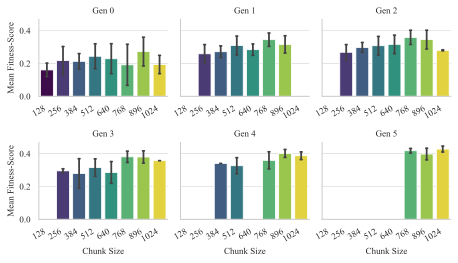

In [4]:
# --- PLOT: CHUNK SIZE ---
# Font size parameter (changeable)
font_size = 9

param = 'chunk_size'
pretty_name = title_map[param]

# Konsistente X-Kategorien aus Gen 0 fÃƒÆ’Ã‚Â¼r gleiche Balkenposition/-dicke in allen Subplots
unique_vals = sorted(df_plot[df_plot['gen'] == 0][param].dropna().unique())

g = sns.catplot(
    data=df_plot,
    x=param, 
    y='fitness',         
    col='gen',           
    col_wrap=3,          
    kind='bar',          
    hue=param,           
    legend=False,        
    capsize=0.1,         
    palette='viridis',
    width=0.8,
    order=unique_vals,
    hue_order=unique_vals,
    sharex=False,        
    sharey=True,         
    errorbar='sd'        
)

# Set exact width from variable (and adjust height proportionally)
g.fig.set_size_inches(width_in_inches, width_in_inches * 0.7)

# Adjust spacing & titles
g.fig.subplots_adjust(top=0.88, bottom=0.22, hspace=0.6, wspace=0.1) 

# Haupttitel mit konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
#g.fig.suptitle(f'Impact of {pretty_name} on Fitness (Generations 0-5)', fontsize=font_size, y=0.98)

# Achsenbeschriftungen mit konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
g.set_axis_labels(pretty_name, "Mean Fitness-Score", fontsize=font_size)

# Subplot-Titel mit konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
g.set_titles("Gen {col_name}", size=font_size) 

# Labels aus Gen 0 fÃƒÂ¼r alle Subplots konsistent formatieren
new_labels = []
for val in unique_vals:
    if float(val).is_integer():
        new_labels.append(str(int(val)))
    else:
        new_labels.append(str(val))

# Special case: Rotate labels for chunk_size und alles auf konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e erzwingen
for ax in g.axes.flat:
    # 1. Zwingt die Zahlen an den Achsen (X und Y) auf exakt die konfigurierte SchriftgrÃƒÂ¶ÃƒÅ¸e
    ax.tick_params(axis='both', which='major', labelsize=font_size)
    
    # 2. X-Ticks auf Gen-0-Kategorien fixieren und Labels konsistent halten
    ax.set_xticks(range(len(unique_vals)))
    ax.set_xticklabels(new_labels, rotation=30, ha='right', fontsize=font_size)
    
    # 3. Sicherheits-Check: Falls einzelne Subplots noch lokale Achsen-Labels haben, diese auch auf konfigurierte SchriftgrÃƒÂ¶ÃƒÅ¸e zwingen
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)

# Speichern als PNG mit 600 DPI
plt.savefig(f'../results/figures/Chunk_size_distribution.svg', format='svg', bbox_inches='tight')
plt.savefig(f'../results/figures/Chunk_size_distribution.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

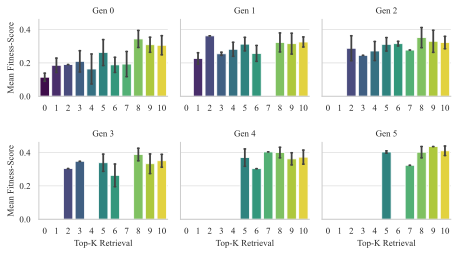

In [5]:
# --- PLOT: TOP-K ---
# Font size parameter (changeable)
font_size = 9

param = 'top_k'
pretty_name = title_map[param]

# Konsistente X-Kategorien aus Gen 0 fÃƒÆ’Ã‚Â¼r gleiche Balkenposition/-dicke in allen Subplots
unique_vals = sorted(df_plot[df_plot['gen'] == 0][param].dropna().unique())

g = sns.catplot(
    data=df_plot,
    x=param, 
    y='fitness',         
    col='gen',           
    col_wrap=3,          
    kind='bar',          
    hue=param,           
    legend=False,        
    capsize=0.1,        
    palette='viridis',
    width=0.8,
    order=unique_vals,
    hue_order=unique_vals,
    sharex=False,        
    sharey=True,         
    errorbar='sd'        
)

# Set exact width from variable
g.fig.set_size_inches(width_in_inches, width_in_inches * 0.7)

# Adjust spacing & titles
g.fig.subplots_adjust(top=0.88, bottom=0.22, hspace=0.6, wspace=0.1) 

# Haupttitel mit konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
#g.fig.suptitle(f'Impact of {pretty_name} on Fitness (Generations 0-5)', fontsize=font_size, y=0.98)

# Achsenbeschriftungen global mit konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
g.set_axis_labels(pretty_name, "Mean Fitness-Score", fontsize=font_size)

# Subplot-Titel mit konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
g.set_titles("Gen {col_name}", size=font_size) 

# Alle Ticks und lokale Achsen-Labels explizit mit konfigurierbarer SchriftgrÃƒÂ¶ÃƒÅ¸e zwingen
new_labels = []
for val in unique_vals:
    if float(val).is_integer():
        new_labels.append(str(int(val)))
    else:
        new_labels.append(str(val))

for ax in g.axes.flat:
    # Zwingt die Zahlen an den Achsen auf exakt die konfigurierte SchriftgrÃƒÂ¶ÃƒÅ¸e
    ax.tick_params(axis='both', which='major', labelsize=font_size)
    
    # X-Ticks rotieren fÃƒÂ¼r bessere Lesbarkeit
    ax.set_xticks(range(len(unique_vals)))
    ax.set_xticklabels(new_labels, rotation=0, ha='center', fontsize=font_size)
    
    # Sicherheits-Check fÃƒÂ¼r lokale Labels
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)

# Speichern als PNG mit 600 DPI
plt.savefig(f'../results/figures/Top_k_distribution.svg', format='svg', bbox_inches='tight')
plt.savefig(f'../results/figures/Top_k_distribution.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

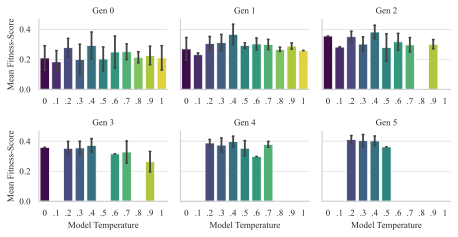

In [6]:
# --- PLOT: TEMPERATURE ---
font_size = 9

param = 'temperature'
pretty_name = title_map[param]

unique_vals = sorted(df_plot[df_plot['gen'] == 0][param].unique())

g = sns.catplot(
    data=df_plot,
    x=param,
    y='fitness',
    col='gen',
    col_wrap=3,
    kind='bar',
    hue=param,
    legend=False,
    capsize=0.1,
    palette='viridis',
    sharex=False,
    sharey=True,
    errorbar='sd',
    width=0.8,
    order=unique_vals  # konsistente Reihenfolge in allen Subplots
)

g.fig.set_size_inches(width_in_inches, width_in_inches * 0.7)
g.fig.subplots_adjust(top=0.88, bottom=0.28, hspace=0.6, wspace=0.1)

g.set_axis_labels(pretty_name, "Mean Fitness-Score", fontsize=font_size)
g.set_titles("Gen {col_name}", size=font_size)

# Labels formatieren
new_labels = []
for val in unique_vals:
    if val == 0.0:
        new_labels.append("0")
    elif val == 1.0:
        new_labels.append("1")
    else:
        new_labels.append(f"{val:.1f}".lstrip('0'))  # 0.5 -> .5

for ax in g.axes.flat:
    # Kategoriale Positionen verwenden (nicht die Float-Werte!)
    ax.set_xticks(range(len(unique_vals)))
    ax.set_xticklabels(new_labels, rotation=0, ha='center', fontsize=font_size)
    ax.tick_params(axis='both', which='major', labelsize=font_size)

#g.fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../results/figures/Temperature_distribution.svg', format='svg', bbox_inches='tight')
plt.savefig('../results/figures/Temperature_distribution.png', format='png', dpi=600, pad_inches=0.3)
plt.show()


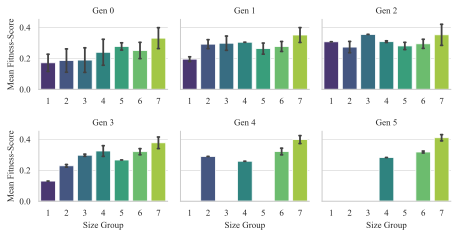

In [7]:
# --- 1. DATA & MAPPING (1-7) ---
df_plot = df.copy()
font_size = 9

cluster_map = {
    # GROUP 1 (Nano)
    'qwen2.5-coder:0.5b-instruct': '1',
    'granite4:350m': '1',
    'gemma3:1b': '1', 
    
    # GROUP 2 (Micro)
    'qwen2.5-coder:1.5b-instruct': '2',
    'deepseek-r1:1.5b': '2',
    'qwen3:1.7b': '2',
    
    # GROUP 3 (Tiny)
    'granite3.1-moe:1b': '3', 
    'granite3.3:2b': '3',
    'qwen3-vl:2b-thinking': '3',

    # GROUP 4 (Small)
    'qwen3-vl:2b-instruct': '4', 
    'qwen2.5-coder:3b-instruct': '4',
    'granite3.1-moe:3b': '4',

    # GROUP 5 (Medium)
    'granite4:micro': '5',
    'phi4-mini:3.8b-q4_K_M': '5', 
    'qwen2.5vl:3b': '5',
 
    # GROUP 6 (Large)
    'gemma3:4b': '6',
    'granite4:tiny-h': '6',
    'gemma3n:e2b': '6', 
    
    # GROUP 7 (Huge)
    'qwen3-coder:30b': '7',
    'gpt-oss:20b': '7',
    'qwen3-vl:30b-a3b-instruct': '7' 
}

# Apply mapping
df_plot['cluster'] = df_plot['model_name'].map(cluster_map)

# --- 2. DIE LÃƒâ€“SUNG (Numerisch + Feste Palette) ---
# Cluster als echte Zahlen speichern (wie bei der Temperatur)
df_plot['cluster'] = pd.to_numeric(df_plot['cluster'])

# Konsistente Cluster-Reihenfolge aus Gen0 (wie beim Temperature-Plot)
unique_clusters = sorted(df_plot[df_plot['gen'] == 0]['cluster'].dropna().unique())

# Feste Farbzuordnung erstellen: 1=Dunkel, 7=Hell
# Dadurch verrutschen die Farben nicht, wenn ein Balken fehlt
colors = sns.color_palette('viridis', n_colors=7)
fixed_palette = {i+1: colors[i] for i in range(7)}

# --- 3. PLOT ---
g = sns.catplot(
    data=df_plot,
    x='cluster',         
    y='fitness',         
    col='gen',           
    col_wrap=3,          
    kind='bar',
    hue='cluster',
    palette=fixed_palette,
    order=unique_clusters,
    hue_order=unique_clusters,
    sharex=False,
    sharey=True,         
    legend=False,        
    errorbar='sd',       
    capsize=0.1
)

# --- 4. FINETUNING ---
g.fig.set_size_inches(width_in_inches, width_in_inches * 0.7)
g.fig.subplots_adjust(top=0.88, bottom=0.28, hspace=0.6, wspace=0.1)

# Haupttitel mit zentral steuerbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
#g.fig.suptitle('Performance by Model Size Group (1=Smallest, 7=Largest)', fontsize=font_size, y=0.98)

# Achsenbeschriftungen global mit zentral steuerbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
g.set_axis_labels("Size Group", "Mean Fitness-Score", fontsize=font_size)

# Subplot-Titel mit zentral steuerbarer SchriftgrÃƒÂ¶ÃƒÅ¸e
g.set_titles("Gen {col_name}", size=font_size)

for ax in g.axes.flat:
    # Kategoriale Positionen verwenden (nicht die Float-Werte)
    ax.set_xticks(range(len(unique_clusters)))
    ax.set_xticklabels([str(int(v)) for v in unique_clusters], rotation=0, ha='center', fontsize=font_size)

    # Y-Grid behalten
    ax.yaxis.grid(True, linestyle='-')
    
    # Zwingt die Zahlen an den Achsen auf exakt die konfigurierte SchriftgrÃƒÂ¶ÃƒÅ¸e
    ax.tick_params(axis='both', which='major', labelsize=font_size)
    
    # Sicherheits-Check fÃƒÂ¼r lokale Labels (falls Seaborn diese generiert)
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), fontsize=font_size)
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), fontsize=font_size)

#g.fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../results/figures/model_cluster_distribution.svg', format='svg', bbox_inches='tight')
plt.savefig('../results/figures/model_cluster_distribution.png', format='png', dpi=600, pad_inches=0.3)
plt.show()

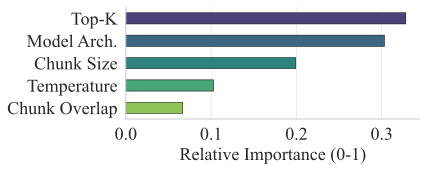

In [8]:
# --- 1. DATA PREPARATION ---
# Aggregate to 1 row per configuration
df_train = df.drop_duplicates(subset=['Hash Id']).copy()
font_size = 18
target = 'fitness'

# Numeric cleaning
for col in ['chunk_size', 'chunk_overlap', 'top_k', 'temperature']:
    df_train[col] = pd.to_numeric(df_train[col], errors='coerce').fillna(0)

# Encode Model Name
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

le = LabelEncoder()
df_train['model_encoded'] = le.fit_transform(df_train['model_name'].astype(str))

# --- THE FIX: CALCULATE SAMPLE WEIGHTS ---
# Count occurrences to fix bias (e.g. 50x Qwen vs 1x Gemma)
model_counts = df_train['model_name'].value_counts()
weights = df_train['model_name'].map(lambda x: 1.0 / model_counts[x])

# Features
X = df_train[['chunk_size', 'chunk_overlap', 'top_k', 'temperature', 'model_encoded']]
y = df_train[target]
feature_names_clean = ['Chunk Size', 'Chunk Overlap', 'Top-K', 'Temperature', 'Model Arch.']

# --- 2. TRAIN RANDOM FOREST (WEIGHTED) ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y, sample_weight=weights)

# --- 3. PLOT A: STANDARD FEATURE IMPORTANCE (BAR PLOT) ---
importances = rf.feature_importances_
df_importance = pd.DataFrame({
    'Feature': feature_names_clean,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(width_in_inches, 2.5))
bar_width = 0.5  # gleiche Balkendicke wie in den Catplots

sns.barplot(
    data=df_importance, 
    x='Importance', 
    y='Feature', 
    palette='viridis', 
    hue='Feature', 
    dodge=False,
    width=bar_width,
    legend=False,
    linewidth=0.5,
    edgecolor='black'
)

# Titel und Labels explizit mit zentral steuerbarer SchriftgrÃ¶ÃŸe
#plt.title('Feature Importance (Weighted Random Forest)', fontsize=font_size, pad=15)
plt.xlabel('Relative Importance (0-1)', fontsize=font_size)
plt.ylabel('', fontsize=font_size)

# Zwingt die Feature-Namen (Y) und die Zahlen (X) auf exakt die konfigurierte SchriftgrÃ¶ÃŸe
plt.tick_params(axis='both', which='major', labelsize=font_size)

plt.grid(axis='x', linestyle='--')
sns.despine() # Removes box frame

plt.tight_layout()
plt.savefig('../results/figures/Feature_Importance_Random_Forest.svg', format='svg', bbox_inches='tight')
plt.savefig('../results/figures/Feature_Importance_Random_Forest.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

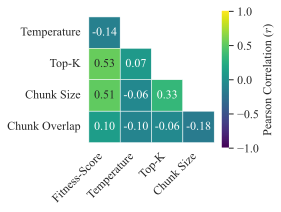

In [9]:
font_size = 12

sns.set_theme(
    style="white",
    context="paper",
    palette="viridis",
    font_scale=1.0,
    rc={
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Computer Modern Roman", "serif"],
        "mathtext.fontset": "cm",
        "font.size": font_size,
        "axes.titlesize": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "axes.linewidth": 1.25,
        "grid.linewidth": 0.75
    }
)

# Hash Id
df_unique = df.drop_duplicates(subset=['Hash Id'])

### 2. Prepare Correlation Matrix
# Define columns to analyze
rename_map = {
    'fitness': 'Fitness-Score', 
    'temperature': 'Temperature', 
    'top_k': 'Top-K', 
    'chunk_size': 'Chunk Size', 
    'chunk_overlap': 'Chunk Overlap'
}

cols = list(rename_map.keys())
corr = df_unique[cols].rename(columns=rename_map).corr()

# Create mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

### 3. Crop Matrix (The "4 Variables" Feature)
# We remove the first row and the last column to hide the empty triangle parts.
# This leaves 4 variables on the Y-axis and 4 variables on the X-axis.
corr_plot = corr.iloc[1:, :-1]
mask_plot = mask[1:, :-1]

### 4. Plot
plt.figure(figsize=(4, 3.5))

ax = sns.heatmap(
    corr_plot, 
    mask=mask_plot, 
    annot=True, 
    annot_kws={"size": font_size},
    fmt=".2f", 
    cmap="viridis", 
    vmin=-1, 
    vmax=1, 
    center=0, 
    square=True, 
    linewidths=0.5, 
    cbar=True,
    cbar_kws={"shrink": 0.8}
)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=font_size)
cbar.set_label("Pearson Correlation ($r$)", size=font_size)

#plt.title(r'Correlation Matrix', fontsize=font_size, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=font_size)
plt.yticks(rotation=0, fontsize=font_size)

plt.tight_layout()
plt.savefig('../results/figures/Korrelationsmatrix.svg', format='svg')
plt.savefig('../results/figures/Korrelationsmatrix.png', format='png', dpi=600)
plt.show()

In [10]:
# Reset style back to global default if needed later
sns.set_theme(
    style="whitegrid",
    context="paper",
    palette="colorblind",
    font_scale=1.0,
    rc={
        # Schriftart auf Serifen stellen (wie in LaTeX/Papers ÃƒÂ¼blich)
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Computer Modern Roman", "serif"],
        
        # Mathe-Formeln ebenfalls im LaTeX-Stil rendern (Computer Modern)
        "mathtext.fontset": "cm",
        
        # StrichstÃƒÂ¤rken fÃƒÂ¼r Paper anpassen (optional, aber empfohlen fÃƒÂ¼r SVG)
        "axes.linewidth": 1.25,
        "grid.linewidth": 0.75
    }
)

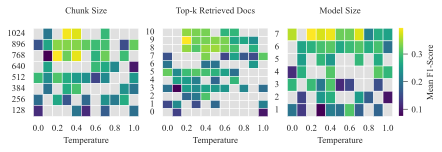

In [14]:
df_log = pd.read_csv('../results/experiments/evolution_computation_log.csv')
font_size = 9

# Define logic for size grouping (GB)
cluster_map = {
    # GROUP 1 (Nano)
    'qwen2.5-coder:0.5b-instruct': '1',
    'granite4:350m': '1',
    'gemma3:1b': '1',

    # GROUP 2 (Micro)
    'qwen2.5-coder:1.5b-instruct': '2',
    'deepseek-r1:1.5b': '2',
    'qwen3:1.7b': '2',

    # GROUP 3 (Tiny)
    'granite3.1-moe:1b': '3',
    'granite3.3:2b': '3',
    'qwen3-vl:2b-thinking': '3',

    # GROUP 4 (Small)
    'qwen3-vl:2b-instruct': '4',
    'qwen2.5-coder:3b-instruct': '4',
    'granite3.1-moe:3b': '4',

    # GROUP 5 (Medium)
    'granite4:micro': '5',
    'phi4-mini:3.8b-q4_K_M': '5',
    'qwen2.5vl:3b': '5',

    # GROUP 6 (Large)
    'gemma3:4b': '6',
    'granite4:tiny-h': '6',
    'gemma3n:e2b': '6',

    # GROUP 7 (Huge)
    'qwen3-coder:30b': '7',
    'gpt-oss:20b': '7',
    'qwen3-vl:30b-a3b-instruct': '7'
}

# Apply mapping to the main dataframe
df_log['cluster_7'] = df_log['model_name'].map(cluster_map)


# --- Helper function for subplots ---
def draw_heatmap_on_ax(ax, data, index, columns, title, ylabel, show_cbar=False, font_size=font_size):
    # Create pivot table
    pivot = data.pivot_table(
        index=index,
        columns=columns,
        values='f1_score',
        aggfunc='mean'
    )

    # Sort index descending
    pivot = pivot.sort_index(ascending=False)

    # Sort temperature columns ascending
    pivot = pivot.reindex(sorted(pivot.columns), axis=1)

    ax.set_facecolor('#e0e0e0')

    sns.heatmap(
        pivot,
        cmap='viridis',
        annot=False,
        linewidths=0.5,
        linecolor='white',
        cbar=show_cbar,
        mask=pivot.isnull(),
        ax=ax
    )

    ax.set_title(title, fontsize=font_size, pad=15, fontweight='normal')
    ax.set_xlabel('Temperature', fontsize=font_size)
    ax.set_ylabel(ylabel, fontsize=font_size)

    ax.tick_params(axis='both', which='major', labelsize=font_size)
    ax.tick_params(axis='y', rotation=0)

    # Show only every second x-axis label: 0.0, 0.2, 0.4, ...
    x_labels = [float(col) for col in pivot.columns]
    tick_positions = []
    tick_labels = []

    for i, value in enumerate(x_labels):
        if round(value * 10) % 2 == 0:
            tick_positions.append(i + 0.5)
            tick_labels.append(f'{value:.1f}')

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=0, fontsize=font_size)

    ax.grid(False)

    if show_cbar:
        cbar = ax.collections[0].colorbar
        cbar.ax.tick_params(labelsize=font_size)
        cbar.set_label('Mean F1-Score', fontsize=font_size)


# Plot initialization
fig, axes = plt.subplots(
    1,
    3,
    figsize=(width_in_inches, width_in_inches / 3),
    constrained_layout=True
)

# --- PLOT 1: Chunk Size ---
draw_heatmap_on_ax(
    ax=axes[0],
    data=df_log,
    index='chunk_size',
    columns='temperature',
    title='Chunk Size',
    ylabel='',
    show_cbar=False,
    font_size=font_size
)

# --- PLOT 2: Top-k ---
draw_heatmap_on_ax(
    ax=axes[1],
    data=df_log,
    index='top_k',
    columns='temperature',
    title='Top-k Retrieved Docs',
    ylabel='',
    show_cbar=False,
    font_size=font_size
)

# --- PLOT 3: Model Cluster ---
draw_heatmap_on_ax(
    ax=axes[2],
    data=df_log,
    index='cluster_7',
    columns='temperature',
    title='Model Size',
    ylabel='',
    show_cbar=True,
    font_size=font_size
)

# Save
plt.savefig(
    '../results/figures/heatmap_f1_temp_chunk_top.svg',
    format='svg',
    bbox_inches='tight'
)

plt.savefig(
    '../results/figures/heatmap_f1_temp_chunk_top.png',
    format='png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

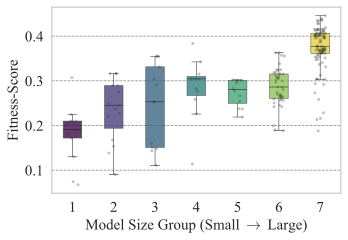

In [12]:
# IMPORTANT: Reduce to individuals (1 point per model configuration)
# Otherwise, we would have millions of points (per question) and the boxplot would be incorrect.
df_model_analysis = df_plot.drop_duplicates(subset=['Hash Id', 'gen']).copy()
font_size = 15

# Drop rows where cluster mapping failed (if any)
df_model_analysis = df_model_analysis.dropna(subset=['cluster'])

# Define strict order
order_list = ['1', '2', '3', '4', '5', '6', '7']

#width_in_inche
# --- 3. PLOT ---
plt.figure(figsize=(width_in_inches * 0.82, 3.5))

# A) Boxplot (Distribution)
ax = sns.boxplot(
    data=df_model_analysis,
    x='cluster',          # Cluster on X-axis
    y='fitness',          # Score on Y-axis
    order=order_list,
    palette='viridis',    # Gradient from Dark (1) to Light (7)
    hue='cluster',
    legend=False,
    linewidth=0.5,        # Etwas dÃƒÂ¼nner fÃƒÂ¼r LaTeX-Look (optional, vorher 1.2)
    width=0.45,
    fliersize=0,          # No outliers (handled by stripplot)
    boxprops=dict(alpha=0.8)
)

# B) Stripplot (Data Points)
sns.stripplot(
    data=df_model_analysis,
    x='cluster',
    y='fitness',
    order=order_list,
    color='#333333',      # Dark Gray
    alpha=0.3,            # Transparent
    jitter=0.14,
    size=3,
    ax=ax
)

# --- 4. DETAILS ---
#plt.title('Performance Distribution by Model Size (Groups 1-7)', fontsize=font_size, pad=20)
plt.ylabel('Fitness-Score', fontsize=font_size)
plt.xlabel('Model Size Group (Small $\\to$ Large)', fontsize=font_size)

# Zwingt die Zahlen/Kategorien an den X- und Y-Achsen auf die konfigurierte SchriftgrÃ¶ÃŸe
ax.tick_params(axis='both', which='major', labelsize=font_size)

plt.grid(axis='y', linestyle='--', color='gray')

plt.tight_layout()
plt.savefig('../results/figures/model_cluster.svg', format='svg', bbox_inches='tight')
plt.savefig('../results/figures/model_cluster.png', format='png', dpi=600, bbox_inches='tight')
plt.show()

C:\Users\Altenbuchner\AppData\Local\Temp\ipykernel_8840\2585570460.py:107: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


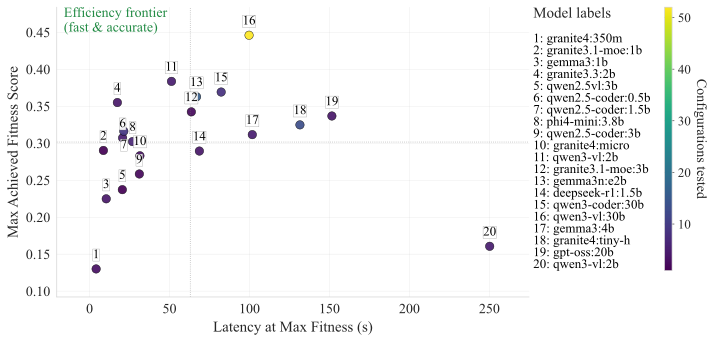

In [18]:
# --- 1. PREPARE DATA ---
df_calc = df.copy()

def extract_latency(metadata_val):
    if pd.isna(metadata_val):
        return None
    try:
        if isinstance(metadata_val, str):
            data = ast.literal_eval(metadata_val)
        elif isinstance(metadata_val, dict):
            data = metadata_val
        else:
            return None

        if isinstance(data, dict) and 'total_duration' in data:
            return float(data['total_duration']) / 1e9

        return None
    except:
        return None


df_calc['latency_seconds'] = df_calc['response_metadata_question'].apply(extract_latency)

model_counts = df.drop_duplicates(subset=['Hash Id'])['model_name'].value_counts()

df_calc = df_calc.dropna(subset=['latency_seconds'])

df_best_models = (
    df_calc
    .sort_values(by='fitness', ascending=False)
    .drop_duplicates(subset=['model_name'])
    .copy()
)

df_best_models['n_trials'] = df_best_models['model_name'].map(model_counts)


# --- 2. PLOT SETUP ---
font_size = 15

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'serif'],
    'font.size': font_size,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

fig = plt.figure(figsize=(width_in_inches * 1.75, width_in_inches * 0.88))

gs = fig.add_gridspec(
    1,
    3,
    width_ratios=[1.0, 0.33, 0.001],
    wspace=0.02,
    left=0.08,
    right=0.92,
    bottom=0.18,
    top=0.94
)

ax = fig.add_subplot(gs[0, 0])
ax_legend = fig.add_subplot(gs[0, 1])
ax_cbar = fig.add_subplot(gs[0, 2])
ax_legend.axis('off')


# --- 3. SCATTER PLOT ---
df_plot_points = df_best_models.sort_values(by='latency_seconds').copy()
df_plot_points['point_id'] = range(1, len(df_plot_points) + 1)

df_plot_points['short_name'] = df_plot_points['model_name'].apply(
    lambda x: '-'.join(str(x).split('-')[0:2])
)

df_plot_points['legend_label'] = [
    f"{pid}: {name}"
    for pid, name in zip(df_plot_points['point_id'], df_plot_points['short_name'])
]

sns.scatterplot(
    data=df_plot_points,
    x='latency_seconds',
    y='fitness',
    ax=ax,
    hue='n_trials',
    palette='viridis',
    s=72,
    edgecolor='black',
    linewidth=0.45,
    alpha=0.92,
    legend=False
)

n_min = df_plot_points['n_trials'].min()
n_max = df_plot_points['n_trials'].max()

if n_min == n_max:
    norm = plt.Normalize(n_min - 0.5, n_max + 0.5)
else:
    norm = plt.Normalize(n_min, n_max)

cmap = plt.cm.get_cmap('viridis')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])


# --- 4. AXIS LIMITS ---
x_min_data = df_plot_points['latency_seconds'].min()
x_max_data = df_plot_points['latency_seconds'].max()
y_min_data = df_plot_points['fitness'].min()
y_max_data = df_plot_points['fitness'].max()

x_range = max(x_max_data - x_min_data, 1e-9)
y_range = max(y_max_data - y_min_data, 1e-9)

x_pad = 0.10 * x_range
y_pad = 0.12 * y_range

ax.set_xlim(x_min_data - x_pad, x_max_data + x_pad)
ax.set_ylim(y_min_data - y_pad, y_max_data + y_pad)
ax.margins(x=0.08, y=0.10)


# --- 5. POINT IDS ---
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
ax_bbox = ax.get_window_extent(renderer=renderer)

placed_bboxes = []
num_fontsize = max(font_size - 2, 7)

candidates = [
    (6, 6, 'left', 'bottom'),
    (-6, 6, 'right', 'bottom'),
    (6, -6, 'left', 'top'),
    (-6, -6, 'right', 'top'),
    (0, 8, 'center', 'bottom'),
    (0, -8, 'center', 'top')
]

for _, row in df_plot_points.iterrows():
    best = None

    for dx, dy, ha, va in candidates:
        txt = ax.annotate(
            str(int(row['point_id'])),
            xy=(row['latency_seconds'], row['fitness']),
            xytext=(dx, dy),
            textcoords='offset points',
            fontsize=num_fontsize,
            ha=ha,
            va=va,
            color='black',
            bbox=dict(
                facecolor='white',
                alpha=0.92,
                edgecolor='#666666',
                linewidth=0.25,
                pad=0.14
            ),
            clip_on=False
        )

        fig.canvas.draw()
        bbox = txt.get_window_extent(renderer=renderer).expanded(1.03, 1.10)
        txt.remove()

        out_of_axes = (
            bbox.x0 < ax_bbox.x0
            or bbox.x1 > ax_bbox.x1
            or bbox.y0 < ax_bbox.y0
            or bbox.y1 > ax_bbox.y1
        )

        overlap_count = sum(bbox.overlaps(prev) for prev in placed_bboxes)

        score = (
            (100 if out_of_axes else 0)
            + overlap_count * 10
            + abs(dx) * 0.01
            + abs(dy) * 0.01
        )

        if best is None or score < best[0]:
            best = (score, dx, dy, ha, va)

            if score == 0:
                break

    _, dx, dy, ha, va = best

    txt = ax.annotate(
        str(int(row['point_id'])),
        xy=(row['latency_seconds'], row['fitness']),
        xytext=(dx, dy),
        textcoords='offset points',
        fontsize=num_fontsize,
        ha=ha,
        va=va,
        color='black',
        bbox=dict(
            facecolor='white',
            alpha=0.92,
            edgecolor='#666666',
            linewidth=0.25,
            pad=0.14
        ),
        clip_on=False
    )

    fig.canvas.draw()
    placed_bboxes.append(
        txt.get_window_extent(renderer=renderer).expanded(1.03, 1.10)
    )


# --- 6. MODEL LABELS ---
legend_fontsize = max(font_size - 2, 7)

ax_legend.set_xlim(0, 1)
ax_legend.set_ylim(0, 1)

legend_title = ax_legend.text(
    0.0,
    1.0,
    'Model labels',
    fontsize=font_size,
    ha='left',
    va='top'
)

label_y0 = 0.91
label_step = min(0.065, 0.82 / max(len(df_plot_points), 1))

legend_text_artists = []

for i, (_, row) in enumerate(df_plot_points.iterrows()):
    txt = ax_legend.text(
        0.0,
        label_y0 - i * label_step,
        row['legend_label'],
        fontsize=legend_fontsize,
        ha='left',
        va='top',
        color='black'
    )
    legend_text_artists.append(txt)


# --- 7. COLORBAR POSITIONED 0.5 CM TO THE RIGHT OF THE LONGEST MODEL LABEL ---
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

legend_pos = ax_legend.get_position()

title_bbox_fig = (
    legend_title.get_window_extent(renderer=renderer)
    .transformed(fig.transFigure.inverted())
)

label_bboxes_fig = [
    txt.get_window_extent(renderer=renderer)
    .transformed(fig.transFigure.inverted())
    for txt in legend_text_artists
]

# rechter Rand der längsten Beschriftung
rightmost_text_x1 = max(
    [title_bbox_fig.x1] +
    [bbox.x1 for bbox in label_bboxes_fig]
)

# oberste und unterste Position aller Texte bestimmen
top_y = max(
    [title_bbox_fig.y1] +
    [bbox.y1 for bbox in label_bboxes_fig]
)

bottom_y = min(
    [title_bbox_fig.y0] +
    [bbox.y0 for bbox in label_bboxes_fig]
)

# 0.5 cm Abstand zwischen letzter Modellbeschriftung und Colorbar
gap_cm = 0.5
gap_fig_x = (gap_cm / 2.54) / fig.get_size_inches()[0]

cbar_width = 0.010
cbar_x0 = rightmost_text_x1 + gap_fig_x

# Colorbar exakt auf Höhe der Modellbeschriftungen begrenzen
ax_cbar.set_position([
    cbar_x0,
    bottom_y,
    cbar_width,
    top_y - bottom_y
])

cbar = fig.colorbar(sm, cax=ax_cbar)

cbar.ax.tick_params(
    labelsize=max(font_size - 2, 7),
    width=0.6,
    length=2.2
)

cbar.outline.set_linewidth(0.6)

cbar.set_label(
    'Configurations tested',
    rotation=270,
    labelpad=16,   # vorher 6
    fontsize=max(font_size - 1, 8)
)


# --- 8. DETAILS & GUIDELINES ---
ax.axvline(
    df_best_models['latency_seconds'].mean(),
    color='0.45',
    linestyle=':',
    linewidth=0.8,
    alpha=0.55
)

ax.axhline(
    df_best_models['fitness'].mean(),
    color='0.45',
    linestyle=':',
    linewidth=0.8,
    alpha=0.55
)

ax.set_xlabel(
    'Latency at Max Fitness (s)',
    fontsize=font_size,
    labelpad=5
)

ax.set_ylabel(
    'Max Achieved Fitness Score',
    fontsize=font_size,
    labelpad=5
)

ax.tick_params(
    axis='both',
    which='major',
    labelsize=max(font_size - 1, 8),
    length=3
)

x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

ax.text(
    x_min,
    y_max,
    "  Efficiency frontier\n  (fast & accurate)",
    color='#238b45',
    ha='left',
    va='top',
    fontsize=max(font_size - 1, 8)
)

ax.grid(
    True,
    linestyle='-',
    linewidth=0.35,
    alpha=0.22,
    color='0.55'
)

ax.set_axisbelow(True)
sns.despine(ax=ax)

plt.savefig(
    '../results/figures/max_fit_vs_latency.svg',
    format='svg',
    bbox_inches='tight'
)

plt.savefig(
    '../results/figures/max_fit_vs_latency.png',
    format='png',
    dpi=600,
    bbox_inches='tight'
)

plt.show()